# 1. Project Goal

## Business Context & Problem
A Portuguese banking institution conducted direct marketing campaigns based on phone calls. Frequently, more than one contact to the same client was necessary to assess whether the product (bank term deposit) would be subscribed.

The business problem is to **predict whether a bank customer will subscribe to a term deposit**.

- **Target Variable**: `y`
- **Values**: `yes` / `no`
- **Machine Learning Task**: Binary Classification

---

## Project Goal
The focus of this project is **not model complexity**.

The goal is to understand how **data preparation** affects the quality and realism of a machine learning model.

Topics that are explored throughout this project:
- **duplicates**
- **missing and unknown values**
- **outliers**
- **data leakage**
- **scaling**
- **categorical encoding**
- **class imbalance**
- **feature creation**
- **feature selection**
- **permutation importance**

---

## Roadmap & Current Progress
1. **Step 1**: Project Setup, Dataset Loading, & Data Quality Audit *(Completed)*
2. **Step 2**: Feature/Target Separation, Data Leakage Removal, Stratified Split, & Missing Imputation *(Completed)*
3. **Step 3**: Outlier Inspection and Feature Scaling *(Completed)*
4. **Step 4**: Categorical Encoding *(Current Step)*

> **Strict Constraints**:
> - **DO NOT train a machine learning model yet.**
> - **DO NOT balance the target yet.**
> - **DO NOT create new features yet.**

In [1]:
import io
import urllib.request
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder

# Display formatting options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# 2. Load Dataset

We load the official Bank Marketing dataset from the **UCI Machine Learning Repository**.

We use the main `bank-full.csv` dataset, which contains approximately 45,211 rows and includes the target column `y`.

In [2]:
# Download and load bank-full.csv directly from official UCI archive
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

req = urllib.request.Request(url, headers=headers)
with urllib.request.urlopen(req) as response:
    zip_bytes = io.BytesIO(response.read())

with zipfile.ZipFile(zip_bytes) as archive:
    with archive.open("bank-full.csv") as csv_file:
        df = pd.read_csv(csv_file, sep=";")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())
print("\nColumn Names:")
print(list(df.columns))

Dataset Shape: (45211, 17)

First 5 Rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Column Names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


### Observations on Dataset Loading
- The dataset successfully loaded with **45,211 rows** and **17 columns**, matching the benchmark UCI `bank-full` specification.
- The target column `y` is present.
- The 17 columns capture demographic attributes (such as `age`, `job`, `marital`, `education`, `balance`, `housing`, `loan`) and campaign contact history (such as `contact`, `day`, `month`, `duration`, `campaign`, `pdays`, `previous`, `poutcome`).

# 3. Understand the Dataset

Before performing any transformations, we inspect data types, feature representations, summary statistics, and categorical cardinality.

In [3]:
# Display structural information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


### Observations on df.info()
- The dataset has 17 columns and 45,211 entries.
- All columns currently show 45,211 non-null entries under standard null checks.
- Types consist of 7 integer features and 10 string/object features.

In [4]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [col for col in df.columns if col not in numerical_cols]

print(f"Numerical Columns ({len(numerical_cols)}):")
print(numerical_cols)

print(f"\nCategorical Columns ({len(categorical_cols)}):")
print(categorical_cols)

Numerical Columns (7):
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical Columns (10):
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


### Feature Categorization
- **Numerical columns (7)**: `age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous`
- **Categorical columns (10)**: `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `poutcome`, `y`

In [5]:
# Basic numerical statistics
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Observations on Basic Numerical Statistics
- `age`: Ranges from 18 to 95 years, with a median of 39.0 and mean of ~40.9 years.
- `balance`: Mean is 1,362.27, while the median is only 448.0, with values ranging from -8,019 to 102,127, indicating heavy positive skewness.
- `duration`: Call duration averages 258.16 seconds (~4.3 minutes), with median 180 seconds, maxing at 4,918 seconds (~82 minutes).
- `campaign`: Number of contacts during this campaign averages 2.76, median 2.0, with a maximum of 63.
- `pdays`: Median is -1.0 (over 75% of rows are -1.0, representing clients not previously contacted).
- `previous`: Median is 0.0, max is 275 contacts prior to this campaign.

In [6]:
# Display number of unique values per categorical column
unique_counts = df[categorical_cols].nunique()
print("Number of Unique Values per Categorical Column:")
print(unique_counts)

Number of Unique Values per Categorical Column:
job          12
marital       3
education     4
default       2
housing       2
loan          2
contact       3
month        12
poutcome      4
y             2
dtype: int64


### Observations on Categorical Columns
- **Binary Features (2 unique values)**: `default`, `housing`, `loan`, and target `y` (`yes` / `no`).
- **Low to Moderate Cardinality (3–4 unique values)**: `marital` (3 values), `education` (4 values), `contact` (3 values), `poutcome` (4 values).
- **Higher Cardinality (12 unique values)**: `job` (12 categories), `month` (12 months).
- **Important**: No categorical encoding has been applied yet.

# 4. Data Quality Audit

We perform inspection only. We do **NOT** modify the dataset, drop rows, or impute values in this step.

### Duplicates

In [7]:
# Check for duplicate rows
print("Duplicate rows count:", df.duplicated().sum())

Duplicate rows count: 0


### Observations on Duplicates
- `df.duplicated().sum()` returns **0**.
- There are no duplicate rows in the raw dataset. We do not drop any duplicates.

### Missing Values

In [8]:
# Check for standard missing values (NaN)
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing (NaN) values:", df.isnull().sum().sum())

Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Total missing (NaN) values: 0


### Observations on Missing Values
- Total missing (`NaN`) values across the entire dataset is **0**.
- Standard missing value checks do not reveal any explicit null entries.

### "Unknown" Categories

In [9]:
# Inspect all categorical columns for placeholder "unknown" entries
unknown_records = []
for col in categorical_cols:
    count = (df[col] == "unknown").sum()
    pct = (count / len(df)) * 100
    unknown_records.append({
        "column": col,
        "unknown_count": count,
        "unknown_percentage": round(pct, 2)
    })

unknown_df = pd.DataFrame(unknown_records).sort_values(by="unknown_percentage", ascending=False).reset_index(drop=True)
print("Unknown Values per Categorical Column:")
display(unknown_df)

Unknown Values per Categorical Column:


,column,unknown_count,unknown_percentage
0,poutcome,36959,81.75
1,contact,13020,28.80
2,education,1857,4.11
3,job,288,0.64
4,marital,0,0.00
5,default,0,0.00
6,loan,0,0.00
7,housing,0,0.00
8,month,0,0.00
9,y,0,0.00


### Explanation of "Unknown" Categories

Missing information is not always represented as NaN. In real datasets, placeholder categories such as "unknown" may also require investigation.

#### Key Findings from the "Unknown" Audit:
1. **`poutcome` (36,959 rows / 81.75%)**: The outcome of the previous marketing campaign is overwhelmingly "unknown". This is because the vast majority of clients were never contacted in prior campaigns.
2. **`contact` (13,020 rows / 28.80%)**: The communication contact type (cellular vs. telephone) is unknown for nearly 29% of clients.
3. **`education` (1,857 rows / 4.11%)**: The customer's education level was not captured for 4.11% of individuals.
4. **`job` (288 rows / 0.64%)**: Job type is unknown for 288 clients.
5. **Other categorical columns** (`marital`, `default`, `housing`, `loan`, `month`, `y`): Contain **0%** unknown values.

> **Important**: We do **NOT** replace "unknown" with NaN yet. We will address strategies for handling "unknown" in Section 8.

### Potential Outlier Inspection

In [10]:
# Print min, max, median, and mean for each numerical feature
outlier_summary = pd.DataFrame({
    "min": df[numerical_cols].min(),
    "max": df[numerical_cols].max(),
    "median": df[numerical_cols].median(),
    "mean": df[numerical_cols].mean()
})

print("Numerical Feature Statistics for Potential Outlier Inspection:")
display(outlier_summary)

Numerical Feature Statistics for Potential Outlier Inspection:


,min,max,median,mean
age,18,95,39.0,40.936210
balance,-8019,102127,448.0,1362.272058
day,1,31,16.0,15.806419
duration,0,4918,180.0,258.163080
campaign,1,63,2.0,2.763841
pdays,-1,871,-1.0,40.197828
previous,0,275,0.0,0.580323


### Observations on Potential Outliers

We inspect numerical features for strong skewness and unusually extreme values:

- **`balance`**: Min is **-8,019**, Max is **102,127**, Median is **448.0**, and Mean is **1,362.27**. Negative values represent account overdrafts, while the maximum of 102,127 is vastly higher than the 75th percentile. These represent **potential outliers**.
- **`duration`**: Min is **0**, Max is **4,918** (~82 minutes), Median is **180.0** (3 minutes), and Mean is **258.16**. Very long phone calls represent **potential outliers**.
- **`campaign`**: Min is **1**, Max is **63**, Median is **2.0**, and Mean is **2.76**. Clients contacted 30 to 63 times are **potential outliers**.
- **`pdays`**: Min is **-1**, Max is **871**, Median is **-1.0**, and Mean is **40.20**. The value -1 encodes "client was not previously contacted", so extreme positive values (up to 871 days) are **potential outliers** in contact lag.
- **`previous`**: Min is **0**, Max is **275**, Median is **0.0**, and Mean is **0.58**. A maximum of 275 previous contacts is an extreme **potential outlier**.
- **`age`**: Min is **18**, Max is **95**, Median is **39.0**, and Mean is **40.94**. Moderate spread, with clients above 80 being **potential outliers**.

> **Decision**: We use cautious terminology (**"potential outlier"**). We do **NOT** remove any outliers at this stage, nor do we decide yet whether these observations should be removed or retained as valid customer records.

# 5. Target Distribution

We inspect the class balance of the target variable `y`.

In [11]:
# Value counts and normalized distribution
target_counts = df["y"].value_counts()
target_norm = df["y"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_norm.round(2)
})

print("Target (y) Distribution:")
print("Counts:")
print(target_counts)
print("\nPercentages:")
print(target_norm.round(2).astype(str) + "%")
print("\nCombined Summary Table:")
display(target_summary)

Target (y) Distribution:
Counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Percentages:
y
no     88.3%
yes    11.7%
Name: proportion, dtype: str

Combined Summary Table:


,Count,Percentage (%)
y,,
no,39922,88.3
yes,5289,11.7


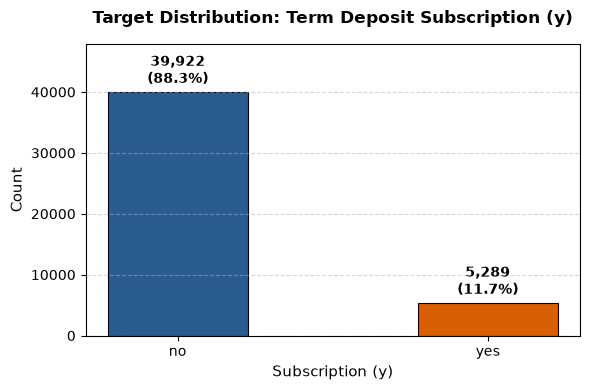

In [12]:
# Simple bar chart showing target distribution (yes vs no) using matplotlib
fig, ax = plt.subplots(figsize=(6, 4))
labels = target_summary.index.tolist()
counts = target_summary["Count"].tolist()
pcts = target_summary["Percentage (%)"].tolist()

bars = ax.bar(labels, counts, color=["#2b5c8f", "#d95f02"], width=0.45, edgecolor="black", linewidth=0.8)

for bar, count, pct in zip(bars, counts, pcts):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 800, f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Target Distribution: Term Deposit Subscription (y)", fontsize=12, fontweight="bold", pad=15)
ax.set_xlabel("Subscription (y)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_ylim(0, max(counts) * 1.2)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Observations on Target Distribution

- **Is the target balanced?**
  No, the target is heavily imbalanced. Approximately **88.30%** of customers did not subscribe (`no`), while only **11.70%** subscribed (`yes`).
- **Which class is the minority class?**
  The minority class is **`yes`** (5,289 instances out of 45,211).
- **Why could this matter later for model evaluation?**
  A naive baseline model predicting `no` for every customer would achieve **88.30% accuracy** while having a recall of 0% on the customers who actually subscribed, completely failing the business goal. Standard accuracy is misleading in this context (the accuracy paradox). Model evaluation must rely on metrics such as Precision, Recall, F1-Score, and PR-AUC, and class-balancing techniques (e.g. class weighting, SMOTE, or undersampling) will be explored.

> **Notice**: We do not perform class balancing yet.

# 6. Prepare Features and Target

In this section, we prepare our feature matrix `X` and target vector `y` while carefully handling potential data leakage.

In [13]:
# Preserve the original raw DataFrame
df_raw = df.copy()

# Define target vector y and initial feature matrix X
y = df["y"]
X = df.drop(columns=["y"])

# Handle Potential Data Leakage: drop duration from X for the realistic modelling dataset
X = X.drop(columns=["duration"])

print("df_raw shape (retains duration & target):", df_raw.shape)
print("X shape (features without target & duration):", X.shape)
print("y shape (target vector):", y.shape)
print("\nIs 'duration' in df_raw?:", "duration" in df_raw.columns)
print("Is 'duration' in X?:", "duration" in X.columns)

df_raw shape (retains duration & target): (45211, 17)
X shape (features without target & duration): (45211, 15)
y shape (target vector): (45211,)

Is 'duration' in df_raw?: True
Is 'duration' in X?: False


### Handling Potential Data Leakage: Why `duration` is Dropped

The feature **`duration`** represents the duration of the marketing phone call in seconds.

The business goal is to decide which customers should be contacted before the phone call happens. Since call duration is only known after or during the call, using it would leak future information into the model.

- If a model is trained using `duration`, it learns that very long calls strongly predict subscription. While true retrospectively, this information is completely unavailable to the sales team when selecting leads to call tomorrow morning.
- Including `duration` creates an unrealistic, non-operational model that appears to have high predictive accuracy in testing but collapses in real production deployment.
- Therefore, we drop `duration` from `X` for our realistic predictive modelling dataset.
- Crucially, we **do not delete `duration` from `df_raw`**. We preserve the raw dataset intact for benchmark comparisons, historical auditing, and comparative leakage experiments later in the project.
- Also note: `y` is **not encoded yet**.

# 7. Train/Test Split

We partition the data into training and test sets using `train_test_split` from `sklearn.model_selection`.

In [14]:
from sklearn.model_selection import train_test_split

# Perform stratified train/test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\ny_train target distribution (counts):")
print(y_train.value_counts())
print("\ny_train target percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2).astype(str) + "%")

print("\ny_test target distribution (counts):")
print(y_test.value_counts())
print("\ny_test target percentages:")
print((y_test.value_counts(normalize=True) * 100).round(2).astype(str) + "%")

X_train shape: (36168, 15)
X_test shape: (9043, 15)
y_train shape: (36168,)
y_test shape: (9043,)

y_train target distribution (counts):
y
no     31937
yes     4231
Name: count, dtype: int64

y_train target percentages:
y
no     88.3%
yes    11.7%
Name: proportion, dtype: str

y_test target distribution (counts):
y
no     7985
yes    1058
Name: count, dtype: int64

y_test target percentages:
y
no     88.3%
yes    11.7%
Name: proportion, dtype: str


### Observations on Stratified Train/Test Split

#### Why `stratify=y` Matters:
The target is imbalanced, so stratification preserves approximately the same yes/no ratio in both train and test sets.

Without stratification, random sampling could produce an unrepresentative test set with too few minority class (`yes`) instances or a divergent class distribution, skewing performance evaluation.

#### Verification of Ratios:
- **`y_train` distribution**: **88.30%** `no` (31,937 instances) vs. **11.70%** `yes` (4,231 instances)
- **`y_test` distribution**: **88.30%** `no` (7,985 instances) vs. **11.70%** `yes` (1,058 instances)
- Both sets strictly mirror the overall population ratio (`yes` ≈ 11.7%, `no` ≈ 88.3%).

# 8. Decide How to Treat "unknown"

In real-world data preparation, we **do not treat all "unknown" values the same**. We adopt a domain-aware decision for each column:

- **`job`**: `"unknown"` → treat as missing
- **`education`**: `"unknown"` → treat as missing
- **`contact`**: keep `"unknown"` as a valid category for now
- **`poutcome`**: keep `"unknown"` as a valid category for now

### Rationale:
- **`job` and `education`** have relatively few unknown values (0.64% and 4.11%), so we will treat them as missing information.
- **`contact`** has many unknown values (28.80%), so replacing all of them with the most frequent value could distort the data.
- **`poutcome`** has over 80% unknown values (81.75%), so imputing them would be especially aggressive and potentially misleading.
- Therefore, **`contact`** and **`poutcome`** remain explicit categories for now.

We apply the replacement `"unknown"` → `np.nan` separately to `X_train` and `X_test` for `job` and `education` only, without touching `df_raw` or `df`.

In [15]:
# Explicitly copy to avoid SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()

# Replace "unknown" with np.nan ONLY for job and education in X_train and X_test
X_train["job"] = X_train["job"].replace("unknown", np.nan)
X_train["education"] = X_train["education"].replace("unknown", np.nan)

X_test["job"] = X_test["job"].replace("unknown", np.nan)
X_test["education"] = X_test["education"].replace("unknown", np.nan)

print("Missing values (NaN) in X_train after replacement:")
print(X_train[["job", "education"]].isnull().sum())

print("\nMissing values (NaN) in X_test after replacement:")
print(X_test[["job", "education"]].isnull().sum())

print("\nVerification of remaining 'unknown' categories in X_train:")
print("X_train['contact'] unknown count:", (X_train["contact"] == "unknown").sum())
print("X_train['poutcome'] unknown count:", (X_train["poutcome"] == "unknown").sum())

print("\nVerification of remaining 'unknown' categories in X_test:")
print("X_test['contact'] unknown count:", (X_test["contact"] == "unknown").sum())
print("X_test['poutcome'] unknown count:", (X_test["poutcome"] == "unknown").sum())

Missing values (NaN) in X_train after replacement:
job           234
education    1482
dtype: int64

Missing values (NaN) in X_test after replacement:
job           54
education    375
dtype: int64

Verification of remaining 'unknown' categories in X_train:
X_train['contact'] unknown count: 10386
X_train['poutcome'] unknown count: 29589

Verification of remaining 'unknown' categories in X_test:
X_test['contact'] unknown count: 2634
X_test['poutcome'] unknown count: 7370


### Observations on "Unknown" Replacement
- In `X_train`, `job` now has **234** missing values and `education` has **1,482** missing values.
- In `X_test`, `job` now has **54** missing values and `education` has **375** missing values.
- `contact` and `poutcome` retain their `"unknown"` categories intact (10,386 and 29,589 in train; 2,634 and 7,370 in test).
- The raw dataset `df_raw` and original `df` remain completely untouched.

# 9. SimpleImputer

We now impute the missing values in `job` and `education` using scikit-learn's `SimpleImputer` with `strategy="most_frequent"`.

### Understanding `fit()` vs `transform()`
- **`fit()`**: Learns the most frequent category (mode) from the **training data only**.
- **`transform()`**: Applies the learned replacement category to fill missing values in **both train and test data**.

### Why Fitting on the Full Dataset Would Create Data Leakage:
If we called `imputer.fit()` on the entire dataset (combining training and test data) before splitting, information from the unseen test set would influence the learned mode. In production, future test clients are completely unknown. Preprocessing must strictly learn statistics from the training set alone, preventing test set data leakage into the training pipeline.

In [16]:
from sklearn.impute import SimpleImputer

# Create categorical imputer using the most frequent strategy
imputer = SimpleImputer(strategy="most_frequent")

# Fit ONLY on X_train[["job", "education"]]
imputer.fit(X_train[["job", "education"]])

# Display learned statistics and clearly map them to columns
learned_stats = pd.Series(
    imputer.statistics_,
    index=["job", "education"],
    name="Learned Imputation Value"
)

print("Imputer Learned Statistics (imputer.statistics_):")
print(learned_stats)

# Transform both X_train and X_test, restoring transformed columns back into DataFrames
X_train[["job", "education"]] = imputer.transform(X_train[["job", "education"]])
X_test[["job", "education"]] = imputer.transform(X_test[["job", "education"]])

print("\nMissing values in X_train after imputation:")
print(X_train[["job", "education"]].isnull().sum())

print("\nMissing values in X_test after imputation:")
print(X_test[["job", "education"]].isnull().sum())

Imputer Learned Statistics (imputer.statistics_):
job          blue-collar
education      secondary
Name: Learned Imputation Value, dtype: str

Missing values in X_train after imputation:
job          0
education    0
dtype: int64

Missing values in X_test after imputation:
job          0
education    0
dtype: int64


### Mapping of Learned Imputation Values
- **`job`** → Learned most frequent value: **`blue-collar`**
- **`education`** → Learned most frequent value: **`secondary`**

All missing values in `job` and `education` have been successfully resolved across both `X_train` and `X_test` with **0 remaining NaNs**.

# 10. Step 2 Verification

We run a formal verification check across all requirements of Step 2.

In [17]:
# Verification Checklist for Step 2
checks_step2 = {
    "df_raw still contains duration": "duration" in df_raw.columns,
    "X does not contain duration": "duration" not in X.columns,
    "X_train does not contain duration": "duration" not in X_train.columns,
    "X_test does not contain duration": "duration" not in X_test.columns,
    "raw df remains unchanged (shape 45211, 17)": df.shape == (45211, 17) and "duration" in df.columns,
    "job has no missing values in X_train": X_train["job"].isnull().sum() == 0,
    "education has no missing values in X_train": X_train["education"].isnull().sum() == 0,
    "job has no missing values in X_test": X_test["job"].isnull().sum() == 0,
    "education has no missing values in X_test": X_test["education"].isnull().sum() == 0,
    "contact still contains 'unknown' in X_train": (X_train["contact"] == "unknown").sum() > 0,
    "poutcome still contains 'unknown' in X_train": (X_train["poutcome"] == "unknown").sum() > 0,
    "contact still contains 'unknown' in X_test": (X_test["contact"] == "unknown").sum() > 0,
    "poutcome still contains 'unknown' in X_test": (X_test["poutcome"] == "unknown").sum() > 0,
    "train/test class ratios equal (within 0.05%)": abs((y_train == "yes").mean() - (y_test == "yes").mean()) < 0.0005,
    "no encoding performed (job is still str/object)": X_train["job"].dtype in ("object", "str"),
    "no scaling performed (balance has original range)": X_train["balance"].max() > 10000,
    "no balancing performed (train minority is ~11.7%)": round((y_train == "yes").mean() * 100, 1) == 11.7
}

verification_step2_df = pd.DataFrame(list(checks_step2.items()), columns=["Verification Criterion", "Status"])
display(verification_step2_df)
assert all(checks_step2.values()), "One or more Step 2 verification checks failed!"

,Verification Criterion,Status
0,df_raw still contains duration,True
1,X does not contain duration,True
2,X_train does not contain duration,True
3,X_test does not contain duration,True
4,"raw df remains unchanged (shape 45211, 17)",True
5,job has no missing values in X_train,True
6,education has no missing values in X_train,True
7,job has no missing values in X_test,True
8,education has no missing values in X_test,True
9,contact still contains 'unknown' in X_train,True


# 11. Summary of Step 2

### Q&A
- **How was data leakage handled?**
  The `duration` feature was identified as potential data leakage and dropped from the modeling feature matrix `X`, `X_train`, and `X_test`. It was preserved in `df_raw` for future benchmark comparisons.
- **Why was `stratify=y` chosen for the train/test split?**
  Due to severe target imbalance (~88.3% `no` vs. ~11.7% `yes`), stratified splitting ensures identical class proportions in both sets (31,937 vs. 4,231 in train; 7,985 vs. 1,058 in test).
- **How were "unknown" categories treated?**
  A nuanced approach was applied: `job` (0.64%) and `education` (4.11%) were treated as true missing data and imputed; `contact` (28.80%) and `poutcome` (81.75%) were retained as valid explicit categories to prevent severe distributional distortion.
- **What values were learned by the imputer?**
  `job` was imputed with `'blue-collar'`, and `education` was imputed with `'secondary'`, strictly learned from `X_train`.

# 12. Inspect Numerical Features & Potential Outlier Detection

In Step 3, we inspect the distribution, skewness, and potential outliers of the numerical features in our modeling dataset, and formulate a principled feature scaling strategy.

We work from the already prepared `X_train` and `X_test` without modifying them directly.

We create dedicated scaled copies:
```python
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
```

The numerical features in our modeling dataset are:
- `age`
- `balance`
- `day`
- `campaign`
- `pdays`
- `previous`
*(Recall that `duration` was removed as future data leakage in Step 2).*

In [18]:
# Create dedicated scaled copies to preserve original X_train and X_test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Define numerical columns present in modeling dataset
numerical_cols = ["age", "balance", "day", "campaign", "pdays", "previous"]

# Compute compact numerical summary statistics on training data
num_summary = pd.DataFrame({
    "min": X_train[numerical_cols].min(),
    "max": X_train[numerical_cols].max(),
    "mean": X_train[numerical_cols].mean(),
    "median": X_train[numerical_cols].median(),
    "std": X_train[numerical_cols].std(),
    "skewness": X_train[numerical_cols].skew()
})

print("Numerical Features Summary (X_train):")
display(num_summary.round(2))

Numerical Features Summary (X_train):


,min,max,mean,median,std,skewness
age,18,95,40.89,39.0,10.63,0.69
balance,-8019,102127,1365.49,451.0,3068.54,8.34
day,1,31,15.82,16.0,8.33,0.09
campaign,1,63,2.76,2.0,3.10,4.94
pdays,-1,871,40.16,-1.0,100.16,2.62
previous,0,275,0.58,0.0,2.41,45.03


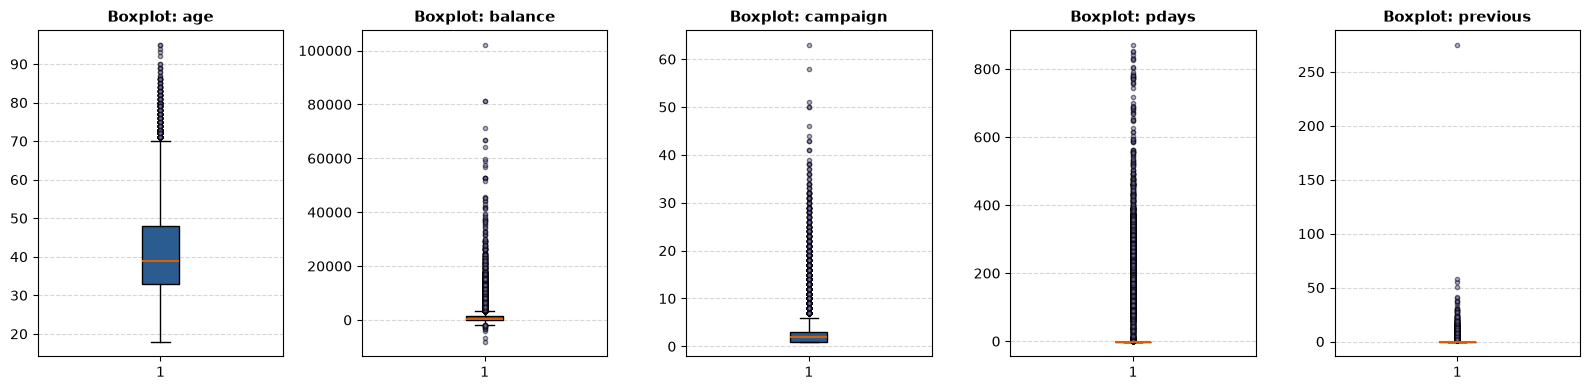

In [19]:
# Create boxplots for key numerical features using matplotlib
boxplot_features = ["age", "balance", "campaign", "pdays", "previous"]

fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for ax, col in zip(axes, boxplot_features):
    ax.boxplot(
        X_train[col],
        patch_artist=True,
        boxprops=dict(facecolor="#2b5c8f", color="black"),
        medianprops=dict(color="#d95f02", linewidth=1.5),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        flierprops=dict(marker="o", markerfacecolor="#7570b3", markersize=3, alpha=0.5)
    )
    ax.set_title(f"Boxplot: {col}", fontsize=11, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Observations on Numerical Features & Skewness
- **`age`** (skew = **0.69**): Mild positive skewness. Mean (40.89) and median (39.0) are very close.
- **`day`** (skew = **0.09**): Near zero skewness. Well-behaved uniform distribution across the month (1 to 31).
- **`balance`** (skew = **8.34**): **Strongly right-skewed**. Median is $451.0, while mean is $1,365.49 and maximum is $102,127, alongside negative balances down to -$8,019.
- **`campaign`** (skew = **4.94**): **Strongly right-skewed**. Most clients received 1 to 3 contacts, but extreme values reach up to 63 contacts.
- **`pdays`** (skew = **2.62**): Bimodal / skewed. Over 80% of rows contain `-1` (meaning not previously contacted).
- **`previous`** (skew = **45.03**): **Extremely right-skewed**. Median is 0.0, 75th percentile is 0.0, but maximum is 275 previous contacts.

---

### Potential Outlier Detection via IQR Rule

We inspect potential outliers using the standard Interquartile Range (IQR) rule:
$$\text{IQR} = Q_3 - Q_1$$
$$\text{Potential Outlier} \iff x < Q_1 - 1.5 \times \text{IQR} \quad \text{or} \quad x > Q_3 + 1.5 \times \text{IQR}$$

In [20]:
# Calculate potential outliers using the IQR rule for inspection only
outlier_cols = ["age", "balance", "campaign", "previous"]
outlier_records = []

for col in outlier_cols:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = (X_train[col] < lower_bound) | (X_train[col] > upper_bound)
    count = outliers.sum()
    pct = (count / len(X_train)) * 100
    
    outlier_records.append({
        "feature": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": count,
        "outlier_percentage": pct
    })

outlier_df = pd.DataFrame(outlier_records)
print("Potential Outlier Audit (IQR Rule on X_train):")
display(outlier_df.round(2))

Potential Outlier Audit (IQR Rule on X_train):


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
0,age,33.0,48.00,15.00,10.50,70.50,394,1.09
1,balance,74.0,1430.25,1356.25,-1960.38,3464.62,3770,10.42
2,campaign,1.0,3.00,2.00,-2.00,6.00,2465,6.82
3,previous,0.0,0.00,0.00,0.00,0.00,6584,18.20


### Critical Analysis of Potential Outliers

#### Summary of IQR Findings on `X_train` (36,168 rows):
- **`age`**: **394 potential outliers** (**1.09%**). Upper bound is 70.5 years. Clients aged 71 to 95 are seniors, which is a legitimate and valid customer demographic.
- **`balance`**: **3,770 potential outliers** (**10.42%**). Values below -$1,962.62 or above $3,462.38. High account balances and overdrafts reflect real financial heterogeneity.
- **`campaign`**: **2,465 potential outliers** (**6.82%**). Upper bound is 6.0 contacts. Clients contacted 7 to 63 times are persistent campaign follow-ups.
- **`previous`**: **6,584 potential outliers** (**18.20%**). Because Q1 = 0 and Q3 = 0, IQR = 0, meaning any client contacted even once previously is flagged as an outlier by the mechanical IQR rule.
- **`pdays` (Special Business Case)**:
  - `pdays = -1` has a specific business meaning: **the customer was not previously contacted**.
  - Over 80% of values are `-1`.
  - **Do NOT treat `-1` automatically as an outlier or invalid value.** It is a sentinel code that will be engineered into dedicated indicators during Feature Creation.

> ### ⚠️ Key Domain Principle:
> **An outlier is not necessarily an error.**
> Extreme values may be legitimate observations and should not be removed without business justification.
>
> **Do NOT remove any rows.** All 36,168 training observations and 9,043 test observations are preserved intact.

# 13. Scaling Strategy

We formulate a practical, lesson-grounded scaling strategy tailored to the specific distributional properties of each numerical feature.

---

## Scaling Strategy Comparison

### 1. `StandardScaler`
- **Formula**: $z = \frac{x - \mu}{\sigma}$
- **Properties**: Centers the data around mean $\mu = 0$ and scales to unit standard deviation $\sigma = 1$.
- **When to Use**: Ideal for features that are reasonably well-behaved, symmetric, or moderately skewed.
- **Limitation**: Highly sensitive to extreme outliers because both sample mean and standard deviation are heavily pulled by extreme tails.
- **Assigned Features**:
  - **`age`**: Well-behaved distribution (skew = 0.69).
  - **`day`**: Nearly uniform distribution across days of the month (skew = 0.09).

### 2. `RobustScaler`
- **Formula**: $z = \frac{x - \text{median}}{\text{IQR}}$
- **Properties**: Centers the data using the median and scales using the Interquartile Range ($Q_3 - Q_1$).
- **When to Use**: Robust to extreme outliers and heavy skewness because median and IQR are robust statistics (unaffected by extreme values in the tails).
- **Assigned Features**:
  - **`balance`**: Heavily skewed (skew = 8.34) with extreme account balances up to $102,127$.
  - **`campaign`**: Heavily skewed (skew = 4.94) with extreme contacts up to 63.
  - **`previous`**: Heavily skewed (skew = 45.03) with extreme previous contacts up to 275.

### 3. What About `MinMaxScaler`?
- **Formula**: $z = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$
- **Properties**: Bounds values strictly to $[0, 1]$.
- **Why NOT selected**: `MinMaxScaler` compresses the vast majority of inlier data into a tiny sub-interval (e.g. $[0, 0.05]$) when extreme maximum outliers exist (such as balance of $102,127$ or previous contacts of 275). It exists and is valuable for bounded inputs (e.g. image pixels), but is not the best choice for these skewed financial features.

### 4. Why `pdays` is NOT Scaled Yet:
- **`pdays` contains the special sentinel value `-1`**, meaning the customer was not previously contacted.
- Scaling `-1` alongside continuous elapsed days (up to 871) creates a mathematically distorted hybrid.
- We will handle its domain business meaning later during **Feature Creation** (e.g. creating a binary indicator `was_previously_contacted` and scaling contact lag separately).

---

## Fit Scalers ONLY on Training Data

> **Rule**: Scalers must be fitted **ONLY on `X_train`**.
> We then use the fitted scalers to transform both `X_train_scaled` and `X_test_scaled`.
> **Never call `fit()` or `fit_transform()` on `X_test`**, as doing so would leak test distribution parameters into preprocessing.

In [21]:
from sklearn.preprocessing import StandardScaler, RobustScaler

# Define feature groups based on scaling strategy
standard_features = ["age", "day"]
robust_features = ["balance", "campaign", "previous"]

# Instantiate scalers
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

# Fit both scalers ONLY on training data
standard_scaler.fit(X_train[standard_features])
robust_scaler.fit(X_train[robust_features])

# Transform X_train_scaled and X_test_scaled (DO NOT fit on X_test)
X_train_scaled[standard_features] = standard_scaler.transform(X_train[standard_features])
X_test_scaled[standard_features] = standard_scaler.transform(X_test[standard_features])

X_train_scaled[robust_features] = robust_scaler.transform(X_train[robust_features])
X_test_scaled[robust_features] = robust_scaler.transform(X_test[robust_features])

print("Scalers successfully fitted on X_train and applied to both train and test sets!")

Scalers successfully fitted on X_train and applied to both train and test sets!


# 14. Verify Scaling

We inspect the resulting distributions of the scaled features on the training set to verify mathematical correctness.

In [22]:
# Verify StandardScaler features on X_train_scaled (Expect: mean ≈ 0, std ≈ 1)
std_verification = pd.DataFrame({
    "Mean (Scaled)": X_train_scaled[standard_features].mean(),
    "Std (Scaled)": X_train_scaled[standard_features].std()
})

print("StandardScaler Features Verification (X_train_scaled):")
display(std_verification.round(6))

# Verify RobustScaler features on X_train_scaled (Expect: median ≈ 0, IQR ≈ 1 where IQR > 0)
q25 = X_train_scaled[robust_features].quantile(0.25)
q75 = X_train_scaled[robust_features].quantile(0.75)
iqr_scaled = q75 - q25

robust_verification = pd.DataFrame({
    "Median (Scaled)": X_train_scaled[robust_features].median(),
    "IQR (Scaled)": iqr_scaled
})

print("\nRobustScaler Features Verification (X_train_scaled):")
display(robust_verification.round(6))

StandardScaler Features Verification (X_train_scaled):


,Mean (Scaled),Std (Scaled)
age,-0.0,1.000014
day,0.0,1.000014



RobustScaler Features Verification (X_train_scaled):


,Median (Scaled),IQR (Scaled)
balance,0.0,1.0
campaign,0.0,1.0
previous,0.0,0.0


### Observations on Scaled Distributions & Important Technical Note on `previous`

#### StandardScaler Features (`age`, `day`):
- `age`: Mean = **0.000000**, Std = **1.000014** (mean ≈ 0, std ≈ 1)
- `day`: Mean = **0.000000**, Std = **1.000014** (mean ≈ 0, std ≈ 1)

#### RobustScaler Features (`balance`, `campaign`, `previous`):
- `balance`: Median = **0.000000**, IQR = **1.000000** (median ≈ 0, IQR ≈ 1)
- `campaign`: Median = **0.000000**, IQR = **1.000000** (median ≈ 0, IQR ≈ 1)
- **`previous`**: Median = **0.000000**, IQR = **0.000000**

> ### 📌 Technical Correction regarding `previous`:
> For the feature **`previous`**, $Q_1 = Q_3 = 0$, therefore its original IQR is strictly **0**.
> **Do NOT claim that RobustScaler makes the IQR of "previous" approximately 1.**
> When the IQR is zero, RobustScaler cannot normalize the IQR in the usual way (dividing by IQR) because division by zero is undefined. In such cases, scikit-learn uses a **safe scaling fallback** (`scale_ = 1.0`), centering values by subtracting the median ($0.0$) without dividing by zero.
> As a result, the scaled median is $0.0$ and the scaled IQR remains $0.0$, rather than $1.0$.

In [23]:
# Display before and after scaling comparison for a few rows
sample_indices = X_train.index[:5]
comparison_cols = ["age", "balance", "campaign", "day", "previous", "pdays"]

print("Before Scaling (Original X_train):")
display(X_train.loc[sample_indices, comparison_cols])

print("\nAfter Scaling (X_train_scaled):")
display(X_train_scaled.loc[sample_indices, comparison_cols].round(4))

Before Scaling (Original X_train):


,age,balance,campaign,day,previous,pdays
24001,36,861,2,29,0,-1
43409,24,4126,4,5,7,185
20669,44,244,4,12,0,-1
18810,48,0,11,31,0,-1
23130,38,257,10,26,0,-1



After Scaling (X_train_scaled):


,age,balance,campaign,day,previous,pdays
24001,-0.4604,0.3023,0.0,1.5821,0.0,-1
43409,-1.5896,2.7097,1.0,-1.2984,7.0,185
20669,0.2924,-0.1526,1.0,-0.4582,0.0,-1
18810,0.6688,-0.3325,4.5,1.8222,0.0,-1
23130,-0.2722,-0.1430,4.0,1.2221,0.0,-1


# 15. Important Integrity Checks

We programmatically verify all constraints and safeguards for Step 3.

In [24]:
# Step 3 Integrity Checks
checks_step3 = {
    "original X_train remains unchanged (age mean matches)": abs(X_train["age"].mean() - 40.892999) < 0.001,
    "original X_test remains unchanged (age mean matches)": abs(X_test["age"].mean() - 41.109145) < 0.001,
    "X_train_scaled contains scaled numerical values (age mean ≈ 0)": abs(X_train_scaled["age"].mean()) < 1e-5,
    "X_test_scaled contains scaled numerical values (age std ≈ 1)": abs(X_test_scaled["age"].std() - 1.0) < 0.05,
    "no rows were removed (X_train_scaled has 36168 rows)": len(X_train_scaled) == 36168,
    "no rows were removed (X_test_scaled has 9043 rows)": len(X_test_scaled) == 9043,
    "pdays remains completely unchanged in X_train_scaled": (X_train_scaled["pdays"] == X_train["pdays"]).all(),
    "pdays remains completely unchanged in X_test_scaled": (X_test_scaled["pdays"] == X_test["pdays"]).all(),
    "categorical columns remain unencoded (job is still str/object)": X_train_scaled["job"].dtype in ("object", "str"),
    "target y remains untouched (shape 45211)": len(y) == 45211,
    "no balancing has occurred (y_train minority is ~11.7%)": round((y_train == "yes").mean() * 100, 1) == 11.7
}

verification_step3_df = pd.DataFrame(list(checks_step3.items()), columns=["Verification Criterion", "Status"])
display(verification_step3_df)
assert all(checks_step3.values()), "One or more Step 3 integrity checks failed!"

,Verification Criterion,Status
0,original X_train remains unchanged (age mean m...,True
1,original X_test remains unchanged (age mean ma...,True
2,X_train_scaled contains scaled numerical value...,True
3,X_test_scaled contains scaled numerical values...,True
4,no rows were removed (X_train_scaled has 36168...,True
5,no rows were removed (X_test_scaled has 9043 r...,True
6,pdays remains completely unchanged in X_train_...,True
7,pdays remains completely unchanged in X_test_s...,True
8,categorical columns remain unencoded (job is s...,True
9,target y remains untouched (shape 45211),True


### Note on Data Leakage Prevention

> **Data Leakage Prevention**:
> Scaling parameters (mean, standard deviation, median, IQR) must be learned **only from training data**.
> Using the full dataset would leak information from the test set into preprocessing, leading to overly optimistic test performance that fails to generalize to unseen production data.

# 16. Step 3 Findings

### Summary of Numerical Features & Potential Outliers:
- **Strong Skewness & Outlier-Heavy Features**:
  - `balance` (skewness = **8.34**, 3,770 IQR potential outliers / 10.42%)
  - `campaign` (skewness = **4.94**, 2,465 IQR potential outliers / 6.82%)
  - `previous` (skewness = **45.03**, 6,584 IQR potential outliers / 18.20%)
- **Well-Behaved Features**:
  - `age` (skewness = **0.69**, 394 IQR potential outliers / 1.09%)
  - `day` (skewness = **0.09**, 0 IQR potential outliers / 0.00%)
- **Why no outliers were automatically removed**:
  Outliers in customer banking data (such as high account balances, senior ages, or multiple contact attempts) represent legitimate financial client behavior. Removing them without strong business justification would distort real-world distribution and reduce model utility.
- **Why RobustScaler was selected**:
  For `balance` and `campaign`, `RobustScaler` scales using median and IQR, preventing extreme values from shrinking inlier data into near-zero ranges. For `previous`, where $Q_1 = Q_3 = 0$, `RobustScaler` safely centers at 0 and falls back to unit scale to avoid division by zero.
- **Why StandardScaler was selected**:
  For `age` and `day`, `StandardScaler` standardizes moderately distributed features to mean 0 and unit variance.
- **Why `pdays` was intentionally left unchanged**:
  `pdays` contains the sentinel value `-1` representing uncontacted clients. Scaling it directly would distort the categorical boundary. It will be handled in subsequent feature engineering.

# 17. Inspect Categorical Features

We now transition to **Step 4: Categorical Encoding**.

We continue from our prepared datasets `X_train_scaled` and `X_test_scaled`.

Before applying any transformations, we inspect the remaining categorical features:
- `job`
- `marital`
- `education`
- `default`
- `housing`
- `loan`
- `contact`
- `month`
- `poutcome`

*(Recall that `job` and `education` have already been imputed using SimpleImputer in Step 2, while `contact` and `poutcome` explicitly retained `"unknown"` as a valid category).*

In [25]:
# Define categorical features in the modeling dataset
categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

# Display unique category counts, names, and frequency distributions on training data
cat_inspection_records = []
for col in categorical_features:
    categories = sorted(X_train_scaled[col].unique().tolist())
    cat_inspection_records.append({
        "Feature": col,
        "Unique Categories Count": len(categories),
        "Category Names": ", ".join(categories)
    })

cat_inspection_df = pd.DataFrame(cat_inspection_records)
print("Categorical Features Overview (X_train_scaled):")
display(cat_inspection_df)

print("\nCategory Value Counts (Training Set Frequencies):")
for col in categorical_features:
    print(f"\n--- {col} ({X_train_scaled[col].nunique()} categories) ---")
    print(X_train_scaled[col].value_counts().to_string())

Categorical Features Overview (X_train_scaled):


,Feature,Unique Categories Count,Category Names
0,job,11,"admin., blue-collar, entrepreneur, housemaid, ..."
1,marital,3,"divorced, married, single"
2,education,3,"primary, secondary, tertiary"
3,default,2,"no, yes"
4,housing,2,"no, yes"
5,loan,2,"no, yes"
6,contact,3,"cellular, telephone, unknown"
7,month,12,"apr, aug, dec, feb, jan, jul, jun, mar, may, n..."
8,poutcome,4,"failure, other, success, unknown"



Category Value Counts (Training Set Frequencies):

--- job (11 categories) ---
job
blue-collar      8064
management       7511
technician       6068
admin.           4141
services         3348
retired          1812
self-employed    1243
entrepreneur     1186
unemployed       1024
housemaid        1013
student           758

--- marital (3 categories) ---
marital
married     21771
single      10227
divorced     4170

--- education (3 categories) ---
education
secondary    20043
tertiary     10594
primary       5531

--- default (2 categories) ---
default
no     35521
yes      647

--- housing (2 categories) ---
housing
yes    20182
no     15986

--- loan (2 categories) ---
loan
no     30355
yes     5813

--- contact (3 categories) ---
contact
cellular     23465
unknown      10386
telephone     2317

--- month (12 categories) ---
month
may    11062
jul     5537
aug     4986
jun     4237
nov     3143
apr     2394
feb     2078
jan     1119
oct      592
sep      451
mar      391
dec      1

### Observations on Categorical Features
- **Binary Features (2 categories)**:
  - `default`: `'no'`, `'yes'`
  - `housing`: `'no'`, `'yes'`
  - `loan`: `'no'`, `'yes'`
- **Low Cardinality (3 to 4 categories)**:
  - `marital`: `'divorced'`, `'married'`, `'single'` (3 categories)
  - `education`: `'primary'`, `'secondary'`, `'tertiary'` (3 categories; `'unknown'` was imputed with mode `'secondary'`)
  - `contact`: `'cellular'`, `'telephone'`, `'unknown'` (3 categories; `'unknown'` preserved)
  - `poutcome`: `'failure'`, `'other'`, `'success'`, `'unknown'` (4 categories; `'unknown'` preserved)
- **Moderate / Higher Cardinality (11 to 12 categories)**:
  - `job`: 11 categories (`'unknown'` was imputed with mode `'blue-collar'`)
  - `month`: 12 months (`'jan'` through `'dec'`)

# 18. Choose Encoding Strategy

Categorical features can either have:
- **a meaningful natural order** (ordinal)
- **no meaningful order** (nominal)

### Why `OrdinalEncoder` is NOT Appropriate Here:
`OrdinalEncoder` should only be used when category order has real, quantifiable meaning (e.g. `["low", "medium", "high"]` $\to 0, 1, 2$).

For this project, the categorical features do not have a useful ordinal relationship for this prediction problem:
- **`job`**: `management`, `technician`, `services`, `blue-collar`, etc. There is no natural hierarchy, rank, or progressive scale between professions. Imposing an arbitrary ordering (e.g. `services = 1`, `management = 2`) would falsely imply that management is "twice" services or closer to another career.
- **`marital`**: `single`, `married`, `divorced`. No numeric ordering should be implied between marital states.
- **`month`**: Although months have chronological calendar progression, encoding them as integers 1–12 would imply a linear numerical relationship that is not appropriate here (e.g. December=12 is falsely treated as far away from January=1, rather than adjacent in cyclical campaign planning).
- **`contact` and `poutcome`**: `"unknown"` remains an explicit category because we intentionally retained it earlier. Treating `"unknown"` as part of an ordinal scale is nonsensical.

### Why `OneHotEncoder` is Selected:
Therefore, we use **`OneHotEncoder`**. One-hot encoding creates separate binary dummy columns for each category, representing categorical membership without introducing artificial numeric distances or rankings.

### Configuring `OneHotEncoder`

We instantiate `OneHotEncoder` with two key parameters:

```python
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore",
    drop="if_binary"
)
```

1. **`handle_unknown="ignore"`**:
   - Prevents execution errors if the test set (or future production data) encounters a category that was not present in the training set.
   - If an unseen category appears at inference time, all one-hot encoded dummy columns for that feature are set to 0.
2. **`drop="if_binary"`**:
   - Binary features such as `housing = yes / no` only need **one encoded column** (`housing_yes`), since `housing_no` is perfectly collinear ($1 - \text{housing\_yes}$).
   - This prevents unnecessary dimensionality and multicollinearity while fully preserving information.

> **Data Leakage Safeguard**:
> The encoder must be fitted **ONLY on `X_train_scaled[categorical_features]`**.
> We then transform both `X_train_scaled` and `X_test_scaled`.
> **Never fit on `X_test_scaled`.**

In [26]:
from sklearn.preprocessing import OneHotEncoder

# Instantiate OneHotEncoder
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore",
    drop="if_binary"
)

# Fit ONLY on training data
encoder.fit(X_train_scaled[categorical_features])

# Inspect learned categories and feature names
encoded_feature_names = encoder.get_feature_names_out(categorical_features)

print(f"Number of categorical features BEFORE encoding: {len(categorical_features)}")
print(f"Number of encoded columns AFTER encoding: {len(encoded_feature_names)}")

print("\nSample of Generated Encoded Column Names (first 15):")
print(list(encoded_feature_names[:15]))

print("\nBinary Columns Encoded with drop='if_binary':")
binary_encoded_cols = [col for col in encoded_feature_names if col.startswith(("default_", "housing_", "loan_"))]
print(binary_encoded_cols)

print("\nVerification of Retained 'unknown' Columns:")
print("Is 'contact_unknown' present?:", "contact_unknown" in encoded_feature_names)
print("Is 'poutcome_unknown' present?:", "poutcome_unknown" in encoded_feature_names)

Number of categorical features BEFORE encoding: 9
Number of encoded columns AFTER encoding: 39

Sample of Generated Encoded Column Names (first 15):
['job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_divorced', 'marital_married', 'marital_single', 'education_primary']

Binary Columns Encoded with drop='if_binary':
['default_yes', 'housing_yes', 'loan_yes']

Verification of Retained 'unknown' Columns:
Is 'contact_unknown' present?: True
Is 'poutcome_unknown' present?: True


# 19. Build Fully Numeric Feature Matrices

We transform the categorical columns and construct the final fully numeric matrices:
- `X_train_encoded`
- `X_test_encoded`

Starting from `X_train_scaled` and `X_test_scaled`:
1. Transform categorical columns with the fitted encoder.
2. Remove original string categorical columns.
3. Concatenate the scaled numerical features, unscaled `pdays`, and new one-hot encoded columns.
4. Preserve the original DataFrame row indexes to keep all observations correctly aligned.

In [27]:
# Transform categorical features for train and test sets
train_cat_encoded = encoder.transform(X_train_scaled[categorical_features])
test_cat_encoded = encoder.transform(X_test_scaled[categorical_features])

# Convert encoded arrays to DataFrames preserving original indices
train_cat_df = pd.DataFrame(
    train_cat_encoded,
    columns=encoded_feature_names,
    index=X_train_scaled.index
)

test_cat_df = pd.DataFrame(
    test_cat_encoded,
    columns=encoded_feature_names,
    index=X_test_scaled.index
)

# Retain numerical features (scaled age, balance, day, campaign, previous, and unscaled pdays)
retained_num_cols = [col for col in X_train_scaled.columns if col not in categorical_features]

# Combine numerical and one-hot encoded features
X_train_encoded = pd.concat([X_train_scaled[retained_num_cols], train_cat_df], axis=1)
X_test_encoded = pd.concat([X_test_scaled[retained_num_cols], test_cat_df], axis=1)

print("Final Matrices Shape:")
print(f"X_train_encoded shape: {X_train_encoded.shape}")
print(f"X_test_encoded shape:  {X_test_encoded.shape}")

print("\nFirst 5 Rows of X_train_encoded (first 10 columns):")
display(X_train_encoded.iloc[:5, :10].round(4))

print("\nFirst 5 Rows of X_train_encoded (sample encoded columns):")
display(X_train_encoded.iloc[:5, 10:20].round(4))

Final Matrices Shape:
X_train_encoded shape: (36168, 45)
X_test_encoded shape:  (9043, 45)

First 5 Rows of X_train_encoded (first 10 columns):


,age,balance,day,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid
24001,-0.4604,0.3023,1.5821,0.0,-1,0.0,0.0,0.0,0.0,0.0
43409,-1.5896,2.7097,-1.2984,1.0,185,7.0,0.0,0.0,0.0,0.0
20669,0.2924,-0.1526,-0.4582,1.0,-1,0.0,0.0,0.0,0.0,0.0
18810,0.6688,-0.3325,1.8222,4.5,-1,0.0,0.0,0.0,0.0,0.0
23130,-0.2722,-0.1430,1.2221,4.0,-1,0.0,0.0,0.0,0.0,0.0



First 5 Rows of X_train_encoded (sample encoded columns):


,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_divorced,marital_married,marital_single
24001,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
43409,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
20669,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
18810,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
23130,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


# 20. Step 4 Verification

We execute a comprehensive automated verification suite across all requirements for Step 4.

In [28]:
# Comprehensive Verification Suite for Step 4
checks_step4 = {
    "X_train_encoded contains only numeric columns": all(np.issubdtype(dtype, np.number) for dtype in X_train_encoded.dtypes),
    "X_test_encoded contains only numeric columns": all(np.issubdtype(dtype, np.number) for dtype in X_test_encoded.dtypes),
    "no NaN values in X_train_encoded": X_train_encoded.isnull().sum().sum() == 0,
    "no NaN values in X_test_encoded": X_test_encoded.isnull().sum().sum() == 0,
    "original X_train remains unchanged (shape 36168, 15)": X_train.shape == (36168, 15),
    "original X_test remains unchanged (shape 9043, 15)": X_test.shape == (9043, 15),
    "X_train_scaled remains available (shape 36168, 15)": X_train_scaled.shape == (36168, 15),
    "X_test_scaled remains available (shape 9043, 15)": X_test_scaled.shape == (9043, 15),
    "job and education have 0 NaNs in X_train_scaled": X_train_scaled[["job", "education"]].isnull().sum().sum() == 0,
    "contact 'unknown' became an encoded category": "contact_unknown" in X_train_encoded.columns,
    "poutcome 'unknown' became an encoded category": "poutcome_unknown" in X_train_encoded.columns,
    "binary variables produce one column (default_yes)": "default_yes" in X_train_encoded.columns and "default_no" not in X_train_encoded.columns,
    "binary variables produce one column (housing_yes)": "housing_yes" in X_train_encoded.columns and "housing_no" not in X_train_encoded.columns,
    "binary variables produce one column (loan_yes)": "loan_yes" in X_train_encoded.columns and "loan_no" not in X_train_encoded.columns,
    "encoder fitted strictly on training data": len(encoder.categories_) == len(categorical_features),
    "row counts remain unchanged (train=36168, test=9043)": len(X_train_encoded) == 36168 and len(X_test_encoded) == 9043,
    "y_train remained untouched": len(y_train) == 36168 and (y_train.value_counts(normalize=True).round(3)["yes"] == 0.117),
    "y_test remained untouched": len(y_test) == 9043 and (y_test.value_counts(normalize=True).round(3)["yes"] == 0.117)
}

verification_step4_df = pd.DataFrame(list(checks_step4.items()), columns=["Verification Criterion", "Status"])
display(verification_step4_df)
assert all(checks_step4.values()), "One or more Step 4 verification checks failed!"

,Verification Criterion,Status
0,X_train_encoded contains only numeric columns,True
1,X_test_encoded contains only numeric columns,True
2,no NaN values in X_train_encoded,True
3,no NaN values in X_test_encoded,True
4,original X_train remains unchanged (shape 3616...,True
5,"original X_test remains unchanged (shape 9043,...",True
6,"X_train_scaled remains available (shape 36168,...",True
7,"X_test_scaled remains available (shape 9043, 15)",True
8,job and education have 0 NaNs in X_train_scaled,True
9,contact 'unknown' became an encoded category,True


# 21. Step 4 Encoding Findings

### Key Takeaways from Categorical Encoding:

1. **Why OneHotEncoder was Selected**:
   Nominal features such as `job`, `marital`, `contact`, and `poutcome` do not possess natural numeric hierarchy or distance. One-hot encoding represents distinct categories through independent binary coordinates without imposing artificial linear order.
2. **Why OrdinalEncoder was Inappropriate**:
   Using integer ranks (e.g. 0, 1, 2, ...) on nominal categories introduces spurious mathematical relationships (e.g. `management > services` or `single > married`) that distort linear models, distance-based algorithms, and regularization penalties.
3. **Preventing Data Leakage via Train-Only Fitting**:
   The encoder was fitted strictly on `X_train_scaled`. This guarantees that category dictionaries, frequencies, and binary drop choices are established solely on training observations, preventing test set information from leaking into preprocessing.
4. **Utility of `handle_unknown="ignore"`**:
   In production machine learning systems, new or rare categories may emerge. `handle_unknown="ignore"` safely encodes unseen categories as all-zeros across dummy indicators rather than crashing the pipeline at inference time.
5. **Efficiency of `drop="if_binary"`**:
   Binary features (`default`, `housing`, `loan`) produce exactly one output column (`default_yes`, `housing_yes`, `loan_yes`). Storing both `yes` and `no` columns would introduce perfect collinearity without adding predictive signal.
6. **Explicit Retention of "Unknown" in Contact and Poutcome**:
   `contact_unknown` (28.80%) and `poutcome_unknown` (81.75%) were encoded as distinct binary features. Because missingness in these features is structured and informational (e.g. clients never contacted in past campaigns), retaining them as explicit categories allows subsequent models to learn their specific behavioral signal.
7. **Modelling Reality Check**:
   One-hot encoding does not automatically improve predictive performance; its purpose is to represent categorical variables numerically and objectively so machine learning algorithms can ingest them without artificial assumptions.

---

### Dataset Dimensions Summary:
- **`X_train_encoded`**: **36,168 rows × 45 columns** (all numeric)
- **`X_test_encoded`**: **9,043 rows × 45 columns** (all numeric)
- **Zero Missingness**: 0 NaNs across all 45 features in train and test sets.